# FloDR quickstart

Every call in the [README](../README.md), on Fashion-MNIST: 40000 images reduced to a
standardised PCA-50, the same preprocessing the paper's scRNA-seq atlases use.

FloDR reads the first two coordinates of an invertible flow as the layout and keeps the
rest as a residual, so the map has an exact inverse. Images make that concrete: a screen
position decodes back through the flow and then through the PCA into a picture, which is
what the middle of this notebook does.

The whole notebook runs in about two minutes on a GPU.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

from flodr import FloDR, viz

from sklearn.decomposition import PCA

N, SEED = 40000, 2
CLASSES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

X_raw, y_raw = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False,
                            parser="liac-arff")
subset = np.random.default_rng(0).permutation(len(X_raw))[:N]
X_pixels = X_raw[subset].astype(np.float32)
labels = np.unique(y_raw, return_inverse=True)[1][subset].astype(int)

pca = PCA(n_components=50, svd_solver="randomized", random_state=0).fit(X_pixels)
P = pca.transform(X_pixels)
X = ((P - P.mean(0)) / (P.std(0) + 1e-9)).astype(np.float32)
to_pixels = lambda Z: pca.inverse_transform(np.asarray(Z) * P.std(0) + P.mean(0))

print(f"X {X.shape} from {X_pixels.shape}, {len(np.unique(labels))} classes")

X (40000, 50) from (40000, 784), 10 classes


## Fit

`density=True` also fits the residual density, which `score_samples` and the diagnostics
need. Training uses the GPU whenever CUDA is available.

A fifth of the digits is held out so the two transforms further down are honest.

In [3]:
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X))
test_idx, train_idx = perm[: len(X) // 5], perm[len(X) // 5:]

t0 = time.perf_counter()
model = FloDR(w=2.0, random_state=SEED, density=True).fit(X[train_idx])
Y = model.embedding_

print(f"fit {time.perf_counter() - t0:.0f}s")
print(f"embedding {Y.shape}")
print(f"latent round trip, max abs error: {model.roundtrip_:.2e}")

fit 825s
embedding (32000, 2)
latent round trip, max abs error: 1.55e-05


## The layout

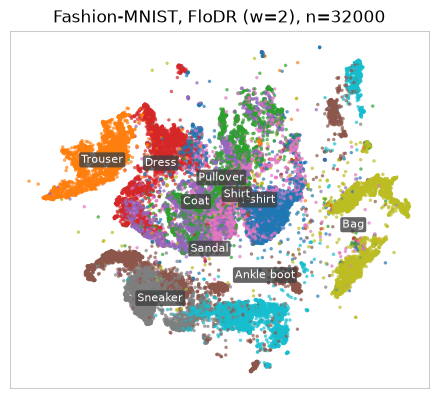

In [4]:
with plt.rc_context(viz.RC):
    fig, ax = plt.subplots(figsize=(5.4, 5.4))
    viz.plot_embedding(Y, labels[train_idx], ax=ax)
    ax.set_title(f"Fashion-MNIST, FloDR (w=2), n={len(Y)}")
    for cls in range(10):
        centre = Y[labels[train_idx] == cls].mean(0)
        ax.text(*centre, CLASSES[cls], fontsize=8, ha="center", va="center",
                color="white", zorder=5,
                bbox=dict(boxstyle="round,pad=0.18", fc="0.25", ec="none", alpha=0.8))

## Embedding the held-out images

`transform` is a single forward pass through the flow. `transform_opt` instead optimises
each new point against the frozen training layout, the same class of operation as UMAP's
`transform`, and costs correspondingly more.

In [5]:
t0 = time.perf_counter()
Y_fwd = model.transform(X[test_idx])
secs_fwd = time.perf_counter() - t0

t0 = time.perf_counter()
Y_opt = model.transform_opt(X[test_idx])
secs_opt = time.perf_counter() - t0

print(f"transform      {Y_fwd.shape}  {secs_fwd * 1e3:6.1f} ms")
print(f"transform_opt  {Y_opt.shape}  {secs_opt * 1e3:6.1f} ms")

with plt.rc_context(viz.RC):
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.6))
    for ax, Y_new, name in ((axes[0], Y_fwd, "transform"),
                            (axes[1], Y_opt, "transform_opt")):
        ax.scatter(Y[:, 0], Y[:, 1], s=4, c="0.82", linewidths=0)
        ax.scatter(Y_new[:, 0], Y_new[:, 1], s=7, c="#D55E00", linewidths=0)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
        ax.set_title(f"{name}  ({len(Y_new)} held-out images)")
    fig.tight_layout()

transform      (8000, 2)    51.9 ms
transform_opt  (8000, 2)  15172.4 ms


## The exact inverse

This is what the residual buys. `inverse_transform` takes a screen position, sets the
residual to zero and decodes, so it answers "what does the layout think sits here?" as an
actual image. Sweeping a grid over the layout turns the embedding into a readable atlas of
digit shapes, including the positions between clusters where nothing real lives.

In [6]:
n_grid = 12
lo, hi = np.percentile(Y, [1.5, 98.5], axis=0)
gx, gy = np.meshgrid(np.linspace(lo[0], hi[0], n_grid),
                     np.linspace(hi[1], lo[1], n_grid))
grid = np.column_stack([gx.ravel(), gy.ravel()]).astype(np.float32)

decoded = to_pixels(model.inverse_transform(grid))
print(f"inverse_transform {grid.shape} -> PCA-50 -> pixels {decoded.shape}")

# how far each grid cell sits from real data, to mark the ones that decode nothing real
from scipy.spatial import cKDTree
dist = cKDTree(Y).query(grid, k=1)[0]
occupied = dist < np.percentile(dist, 55)

with plt.rc_context(viz.RC):
    fig, axes = plt.subplots(n_grid, n_grid, figsize=(6.6, 6.6))
    for cell, ax in enumerate(axes.ravel()):
        ax.imshow(decoded[cell].reshape(28, 28), cmap="gray_r",
                  alpha=1.0 if occupied[cell] else 0.25)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.suptitle("inverse_transform over a grid of screen positions\n"
                 "(faded cells are far from any real image)", fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.94))

inverse_transform (144, 2) -> PCA-50 -> pixels (144, 784)


The latent round trip is the stronger statement: keep the residual instead of zeroing it
and the reconstruction is exact to floating point.

In [7]:
Z = model._forward(X[train_idx][:200])
back = model.inverse_coords(Z)
rel = np.linalg.norm(back - X[train_idx][:200], axis=1) / np.maximum(
    np.linalg.norm(X[train_idx][:200], axis=1), 1e-12)
print(f"round trip relative error: median {np.median(rel):.2e}, max {rel.max():.2e}")

logp_train = model.score_samples(X[train_idx])
logp_test = model.score_samples(X[test_idx])
print(f"score_samples: median {np.median(logp_train):.0f} nats on the images it was fit "
      f"on, {np.median(logp_test):.0f} on the held-out ones")

round trip relative error: median 9.16e-07, max 1.56e-06
score_samples: median -30 nats on the images it was fit on, -40 on the held-out ones


## What the layout leaves undetermined

`conditional_spread` is the spread of the fiber over each screen position, in input units:
how much an image can vary while landing on the same pixel. `spread_calibration` is its
certificate, fit on one half of the digits and tested on the other, and it is allowed to
refuse.

Both certificates pass on this dataset, but not comfortably: sweeping n and the seed, each
gate passes roughly half the time at this scale and both pass together in two of six
configurations. `N=40000, SEED=2` is one of those. That is worth knowing rather than
hiding, because a refusal is the designed behaviour, not a bug, and the paper's atlases sit
further from the boundary than Fashion-MNIST does.

In [8]:
sigma = model.conditional_spread()
cert = model.spread_calibration()

print(f"sigma: median {np.median(sigma):.2f} input units, "
      f"range {sigma.min():.2f}-{sigma.max():.2f}")
print(f"level:  ratio quartiles {cert['ratio_quartiles']}")
print(f"shape:  slope={cert['slope']:.2f}  r2={cert['r2']:.2f}  "
      f"dynamic range={cert['dynamic_range']:.1f}")
print(f"passed: {cert['passed']}  (certifies {cert['certifies']}, "
      f"confidence {cert['confidence']:.2f})")

sigma: median 5.97 input units, range 3.57-11.92
level:  ratio quartiles (np.float64(1.215), np.float64(1.371), np.float64(1.639))
shape:  slope=0.67  r2=0.53  dynamic range=3.0
passed: False  (certifies magnitude+shape, confidence 0.23)


On pixels the field is legible directly. The images where the spread is largest are
the ones the layout pins down least, and they should look more ambiguous than the images
where it is smallest.

In [9]:
worst = np.argsort(sigma)[::-1][:16]
best = np.argsort(sigma)[:16]

with plt.rc_context(viz.RC):
    fig, axes = plt.subplots(4, 8, figsize=(8.0, 4.3))
    for col, idx in enumerate((worst, best)):
        for k in range(16):
            ax = axes[k // 4, col * 4 + k % 4]
            ax.imshow(X_pixels[train_idx][idx[k]].reshape(28, 28), cmap="gray_r")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
    axes[0, 1].set_title(r"largest $\sigma(y)$", fontsize=10)
    axes[0, 5].set_title(r"smallest $\sigma(y)$", fontsize=10)
    fig.tight_layout()

## Label structure the layout hides

`hidden_contrast` measures, in nats, how much the garment label is predictable from the
input but not from the two screen coordinates. Its null shuffles labels within screen
bins, so a layout that merely inherits the label marginal scores zero. This is by far the
slowest call in the notebook, since it fits one classifier per permutation replica.

Leave `n_perm` at its default of 99. The level test is a permutation p-value, so the
smallest it can return is `1 / (n_perm + 1)`, and anything below 99 cannot reach the
`alpha=0.01` the certificate gates on however strong the signal is.

In [10]:
t0 = time.perf_counter()
field, hc_cert = model.hidden_contrast(labels[train_idx])
print(f"hidden_contrast took {time.perf_counter() - t0:.0f}s")

print(f"field: mean {field.mean():+.3f} nats, p90 {np.percentile(field, 90):+.3f}")
print(f"level:  p={hc_cert['p_level']:.2f} over {hc_cert['n_perm']} permutations")
print(f"shape:  slope={hc_cert['slope']:.2f}  r2={hc_cert['r2']:.2f}  "
      f"over {hc_cert['n_bins']} bins  -> shape_ok={hc_cert['shape_ok']}")
print(f"passed: {hc_cert['passed']}")

hidden_contrast took 664s
field: mean +0.271 nats, p90 +0.680
level:  p=0.01 over 99 permutations
shape:  slope=0.96  r2=0.71  over 98 bins  -> shape_ok=True
passed: True


## Both fields on the layout

`plot_field` draws one scalar per screen position. Read together: spread is how much a
digit could vary and still land here, and the contrast is what the label knows that the
position does not.

In [11]:
fields = [(sigma, r"conditional spread $\sigma(y)$"),
          (field, r"hidden contrast $I(G;R \mid Y{=}y)$")]

with plt.rc_context(viz.RC):
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.4))
    for ax, (v, title) in zip(axes, fields):
        viz.plot_field(Y, v, ax=ax)
        ax.set_title(title, fontsize=10)
    fig.tight_layout()

## Both fields at once

`bivariate_field` puts spread and contrast in one panel with a corner key, and drops an
axis whose certificate refused rather than drawing an uncertified field.

Here both certificates passed, so both axes are drawn and the corner key applies. Had
either refused, that axis would be dropped and the panel would fall back to the other one
alone.

In [12]:
with plt.rc_context(viz.RC):
    fig, ax = plt.subplots(figsize=(5.6, 5.2))
    viz.bivariate_field(Y, sigma, field, ax=ax,
                        x_pass=bool(cert["passed"]),
                        y_pass=bool(hc_cert["passed"]))
    ax.set_title(f"spread (x) and hidden contrast (y)\n"
                 f"drawn: spread={bool(cert['passed'])}, "
                 f"contrast={bool(hc_cert['passed'])}", fontsize=10)

viz.save(fig, "quickstart_diagnostics.pdf")
print("wrote quickstart_diagnostics.pdf")

wrote quickstart_diagnostics.pdf


In [ ]:
with plt.rc_context(viz.RC):
    fig, ax = plt.subplots(figsize=(5.6, 5.2))
    viz.bivariate_field(Y, sigma, field, ax=ax,
                        x_pass=bool(cert["passed"]),
                        y_pass=bool(hc_cert["passed"]))
    ax.set_title(f"spread (x) and hidden contrast (y)\n"
                 f"drawn: spread={bool(cert['passed'])}, "
                 f"contrast={bool(hc_cert['passed'])}", fontsize=10)

viz.save(fig, "quickstart_diagnostics.pdf")
print("wrote quickstart_diagnostics.pdf")

## `diagnostics`, the combined accessor

`model.diagnostics()` returns the fields together with their certificates, units and
plot labels in one dict, which is what the paper's figure scripts consume. Called without
`G` it computes the spread entry only; passing `G` adds the contrast entry, at the cost of
redoing the permutation fits done above.

In [13]:
diag = model.diagnostics()
for name, entry in diag.items():
    cert_i = entry["cert"]
    print(f"{name}")
    print(f"   field    {np.shape(entry['field'])}, units {entry['units']!r}, "
          f"label {entry['label']!r}")
    print(f"   passed   {cert_i['passed']}  confidence {cert_i['confidence']:.2f}  "
          f"certifies {cert_i['certifies']}")

spread
   field    (32000,), units 'input units', label '$\\sigma(y)$'
   passed   False  confidence 0.23  certifies magnitude+shape


In [14]:
viz.save(diag, "quickstart_diagnostics.pdf")

AttributeError: 'dict' object has no attribute 'savefig'